# Testing Performance Metrics For The Agent

In [1]:
import pandas as pd

In [2]:
df = pd.read_json("sms_conversations.json")

In [3]:
df

,conversation_id,candidate_phone,recruiter_phone,start_time_utc,turns
0,1,+1-555-0201,+1-555-0000,2026-04-03T15:12:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
1,2,+1-555-0202,+1-555-0000,2026-04-30T11:19:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
2,3,+1-555-0203,+1-555-0000,2026-04-10T16:02:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
3,4,+1-555-0204,+1-555-0000,2026-04-28T11:13:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
4,5,+1-555-0205,+1-555-0000,2026-04-26T12:43:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
5,6,+1-555-0206,+1-555-0000,2026-04-16T16:45:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
6,7,+1-555-0207,+1-555-0000,2026-04-12T12:15:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
7,8,+1-555-0208,+1-555-0000,2026-04-03T12:49:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
8,9,+1-555-0209,+1-555-0000,2026-04-17T17:20:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
9,10,+1-555-0210,+1-555-0000,2026-04-27T13:30:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."


## The Data

<p>
We got some conversations to test on: the file contains <i>convesation id</i> which is equivalent to <i>Session id</i> in our code, some <i>meta data</i> on the conversation, and the <i>turns</i> in each conversation.
</p>
<p>
We need to create a turn based test bench, which takes the turns in each conversation and checks if the agent is following the script as he should or not.
</p>



### The Evaluation Process is as follows: 
1. Load the conversations - already done up there
2. Extract the label from each turn in each conversation.
3. Extract the initial prompt from each conversation.
4. Extract the user's prompts from each conversation.
5. Start the Agent with the initial response.
6. Send the user's prompt to the Agent in each turn.
7. Get the agent's response and intention for each user prompt.
8. Evaluate the agent's intention against the extracted label.
9. Save the agent's intentions into an array.
10. Create a confusion matrix for each label ('continue', 'schedule', 'exit')


In [ ]:
import os
from dotenv import load_dotenv

os.chdir('../')
os.getcwd()


In [5]:
from langchain.tools import tool
from app.modules.agents.agents import Agent
from app.modules.embedding import build_search_job_description_tool, Embedder
from app.modules.sql_interface.schedule_db import build_schedule_tools

load_dotenv()

# ollama chat llms: gemma4:e4b

# Create an Embedding db if not found:
if 'chroma_db' not in os.listdir():
    embed = Embedder()

    embed.build_vectorstore('../Python Developer Job Description.pdf')

# Create the info tool function
load_info = build_search_job_description_tool()

# Create schedule tools with db connection, using python dev as default position
schedule_tools = build_schedule_tools()

In [6]:
for i,r in df.iterrows():
    print(r)

conversation_id                                                    1
candidate_phone                                          +1-555-0201
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-03T15:12:00Z
turns              [{'turn_id': 1, 'speaker': 'recruiter', 'times...
Name: 0, dtype: object
conversation_id                                                    2
candidate_phone                                          +1-555-0202
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-30T11:19:00Z
turns              [{'turn_id': 1, 'speaker': 'recruiter', 'times...
Name: 1, dtype: object
conversation_id                                                    3
candidate_phone                                          +1-555-0203
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-1

In [ ]:
intentions_list = []

for i,r in df.iterrows():
    user_message = None
    message = r['turns'][0]['text']
    @tool
    def get_conversation_time()-> str:
        '''Returns the start time of the conversation.'''
        return r['start_time_utc']

    sys_msg =f""""The User's application has been received successfully. The User will be redirected to you."
    Output exactly this: {message},
    to the user **First**, and after that you can continue normally."""

    agent = Agent(
        api_key="ollama",
        model="gemma4:e4b", 
        base_url="http://localhost:11434/v1",
        system_message=sys_msg,
        sch_tools=schedule_tools+[get_conversation_time],
        info_tools=[load_info],
        temperature = 0,
        verbose=False
    )

    for turn in r['turns']:
        print('-'*60)
        if turn['turn_id'] == 1:
            ai_mesasge = agent.step('candidate')
        # at candidate turn generate the ai response
        if turn['speaker'] == 'candidate':
            print(turn['text'])
            ai_mesasge = agent.step('candidate', turn['text'])
        # at the recruiter turn print the response and the intention
        elif turn['speaker'] == 'recruiter':
            print(ai_mesasge['response'])
            print('Recruiter Label:')
            print(turn['label'])
            print('Assistant Label:')
            try:
                intentions_list.append((i, turn['turn_id'], ai_mesasge['intention']))
                print(ai_mesasge['intention'])
            except IndexError:
                intentions_list.append((i, turn['turn_id'], 'continue'))
                print('Error:', 'continue')

    print('-'*60)
    print('Agent Intentions in the conversation:')
    print(intentions_list)
    print('-'*60)
    print('Summaries in conversation:')
    print(agent.summary_counter)


In [8]:
test_df = pd.DataFrame(intentions_list)
test_df.head()

,0,1,2
0,0,1,continue
1,0,3,continue
2,0,5,end
3,0,7,end
4,1,1,continue


In [9]:
test_df = test_df.rename(columns={0:'conversation_id', 1:'turn_id', 2:'intention'})
test_df['conversation_id'] += 1
test_df.head()

,conversation_id,turn_id,intention
0,1,1,continue
1,1,3,continue
2,1,5,end
3,1,7,end
4,2,1,continue


In [10]:
tmp = pd.DataFrame()
for i,turn in enumerate(df.turns):
    tmp_df = pd.DataFrame(turn)
    tmp_df['conversation_id'] = i+1
    tmp = pd.concat([tmp,tmp_df],ignore_index=True)
tmp.head()

,turn_id,speaker,timestamp_utc,text,label,conversation_id
0,1,recruiter,2026-04-03T15:12:00Z,Thanks for applying to our Python Developer op...,continue,1
1,2,candidate,2026-04-03T15:13:19Z,I've been using Python professionally for five...,NaN,1
2,3,recruiter,2026-04-03T15:15:01Z,Our engineering manager can interview you Wedn...,schedule,1
3,4,candidate,2026-04-03T15:15:33Z,I can't at that time—I'm busy.,NaN,1
4,5,recruiter,2026-04-03T15:16:23Z,No problem. How about Thursday at 4 PM instead?,schedule,1


In [11]:
labels_df=tmp[tmp['speaker']=='recruiter'][['conversation_id','turn_id','label']]
labels_df.head()

,conversation_id,turn_id,label
0,1,1,continue
2,1,3,schedule
4,1,5,schedule
6,1,7,end
7,2,1,continue


In [12]:
dfs = pd.merge(test_df, labels_df,on=['conversation_id','turn_id'])
dfs.head()

,conversation_id,turn_id,intention,label
0,1,1,continue,continue
1,1,3,continue,schedule
2,1,5,end,schedule
3,1,7,end,end
4,2,1,continue,continue


In [13]:
dfs.intention = dfs.intention.str.replace("exit",'end')
dfs.head()

,conversation_id,turn_id,intention,label
0,1,1,continue,continue
1,1,3,continue,schedule
2,1,5,end,schedule
3,1,7,end,end
4,2,1,continue,continue


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


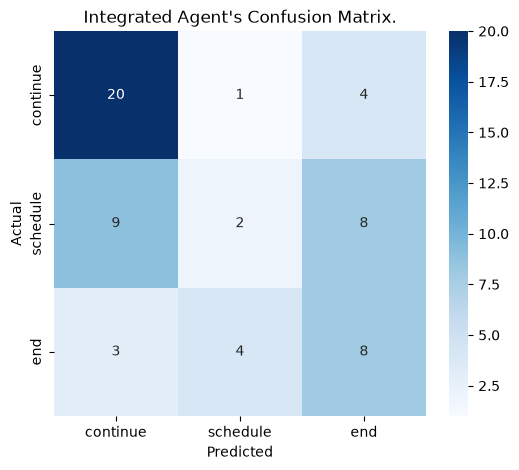

In [15]:
cf = confusion_matrix(dfs.label, dfs.intention,labels=['continue', 'schedule', 'end'])

plt.figure(figsize=(6,5))
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.title("Integrated Agent's Confusion Matrix.")
plt.xticks([0.5,1.5,2.5],labels=['continue', 'schedule', 'end'])
plt.yticks([0.5,1.5,2.5],labels=['continue', 'schedule', 'end'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Conclusion so far
<p>
We Can see from the confusion matrix that the currently used model <i><code>gemma4:e4b</code></i> is getting confused in the scheduling phase.
</p>
<p>
The cause can be that the model is a small model, or that the instructions are somehow confusing it.
</p>